## Analysis Workflow

1. Load and inspect the data
2. Aggregate logins into 15-minute intervals
3. Explore the resulting time series
4. Examine daily and weekly demand patterns
5. Identify potential data quality issues
6. Summarize key findings

# Part 1: Exploratory Data Analysis

## Objective

The objective of this analysis is to explore patterns in user login activity using the provided `logins.json` dataset. According to the challenge instructions, login events will be aggregated into **15-minute intervals** and analyzed to identify temporal patterns in user demand. :contentReference[oaicite:0]{index=0}

The analysis will focus on:

- Aggregating login events into 15-minute time bins.
- Visualizing login activity over time.
- Identifying daily and weekly usage cycles.
- Detecting trends, seasonality, and unusual behavior.
- Assessing the data for any potential quality issues.

Understanding these temporal demand patterns can provide valuable insights into user behavior and help inform operational decisions such as resource allocation, staffing, and system capacity planning.

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

import seaborn as sns

import json
from pathlib import Path

from matplotlib.ticker import PercentFormatter


In [2]:
# Define the path to the login data
login_path = Path("logins.json")

# Confirm that the file exists
if not login_path.exists():
    raise FileNotFoundError(f"Could not find {login_path.resolve()}")

# Load the raw JSON data
with open(login_path, "r") as file:
    login_data = json.load(file)

# Inspect the structure of the parsed JSON
print(f"Parsed object type: {type(login_data)}")

if isinstance(login_data, dict):
    print(f"Dictionary keys: {login_data.keys()}")
    
    for key, value in login_data.items():
        print(f"\nKey: {key}")
        print(f"Value type: {type(value)}")
        
        if hasattr(value, "__len__"):
            print(f"Number of values: {len(value):,}")
        
        print(f"First five values: {value[:5] if isinstance(value, list) else value}")
else:
    print(f"Number of records: {len(login_data):,}")
    print(f"First five records: {login_data[:5]}")

Parsed object type: <class 'dict'>
Dictionary keys: dict_keys(['login_time'])

Key: login_time
Value type: <class 'list'>
Number of values: 93,142
First five values: ['1970-01-01 20:13:18', '1970-01-01 20:16:10', '1970-01-01 20:16:37', '1970-01-01 20:16:36', '1970-01-01 20:26:21']


In [3]:
# Convert the login timestamps into a DataFrame
logins = pd.DataFrame(login_data)

# Convert to datetime
logins["login_time"] = pd.to_datetime(logins["login_time"])

# Inspect
display(logins.head())
logins.info()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


<class 'pandas.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 727.8 KB


In [4]:
print(f"Number of rows: {len(logins):,}")
print(f"Missing or invalid timestamps: {logins['login_time'].isna().sum():,}")
print(f"Duplicate timestamps: {logins['login_time'].duplicated().sum():,}")
print(f"Earliest login: {logins['login_time'].min()}")
print(f"Latest login: {logins['login_time'].max()}")

Number of rows: 93,142
Missing or invalid timestamps: 0
Duplicate timestamps: 877
Earliest login: 1970-01-01 20:12:16
Latest login: 1970-04-13 18:57:38


Although 877 timestamps are duplicated, these represent simultaneous login events rather than duplicate records. Since the objective is to count login activity over 15-minute intervals, repeated timestamps are expected and should be retained.

In [5]:
# Aggregate login counts into 15-minute intervals
login_counts = (
    logins
    .set_index("login_time")
    .resample("15min")
    .size()
    .rename("login_count")
    .to_frame()
)

display(login_counts.head(10))

,login_count
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1
1970-01-01 21:15:00,4
1970-01-01 21:30:00,0
1970-01-01 21:45:00,4
1970-01-01 22:00:00,9


In [6]:
print(login_counts.info())

print(f"\nNumber of 15-minute intervals: {len(login_counts):,}")
print(f"Total logins: {login_counts['login_count'].sum():,}")

<class 'pandas.DataFrame'>
DatetimeIndex: 9788 entries, 1970-01-01 20:00:00 to 1970-04-13 18:45:00
Freq: 15min
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   login_count  9788 non-null   int64
dtypes: int64(1)
memory usage: 152.9 KB
None

Number of 15-minute intervals: 9,788
Total logins: 93,142


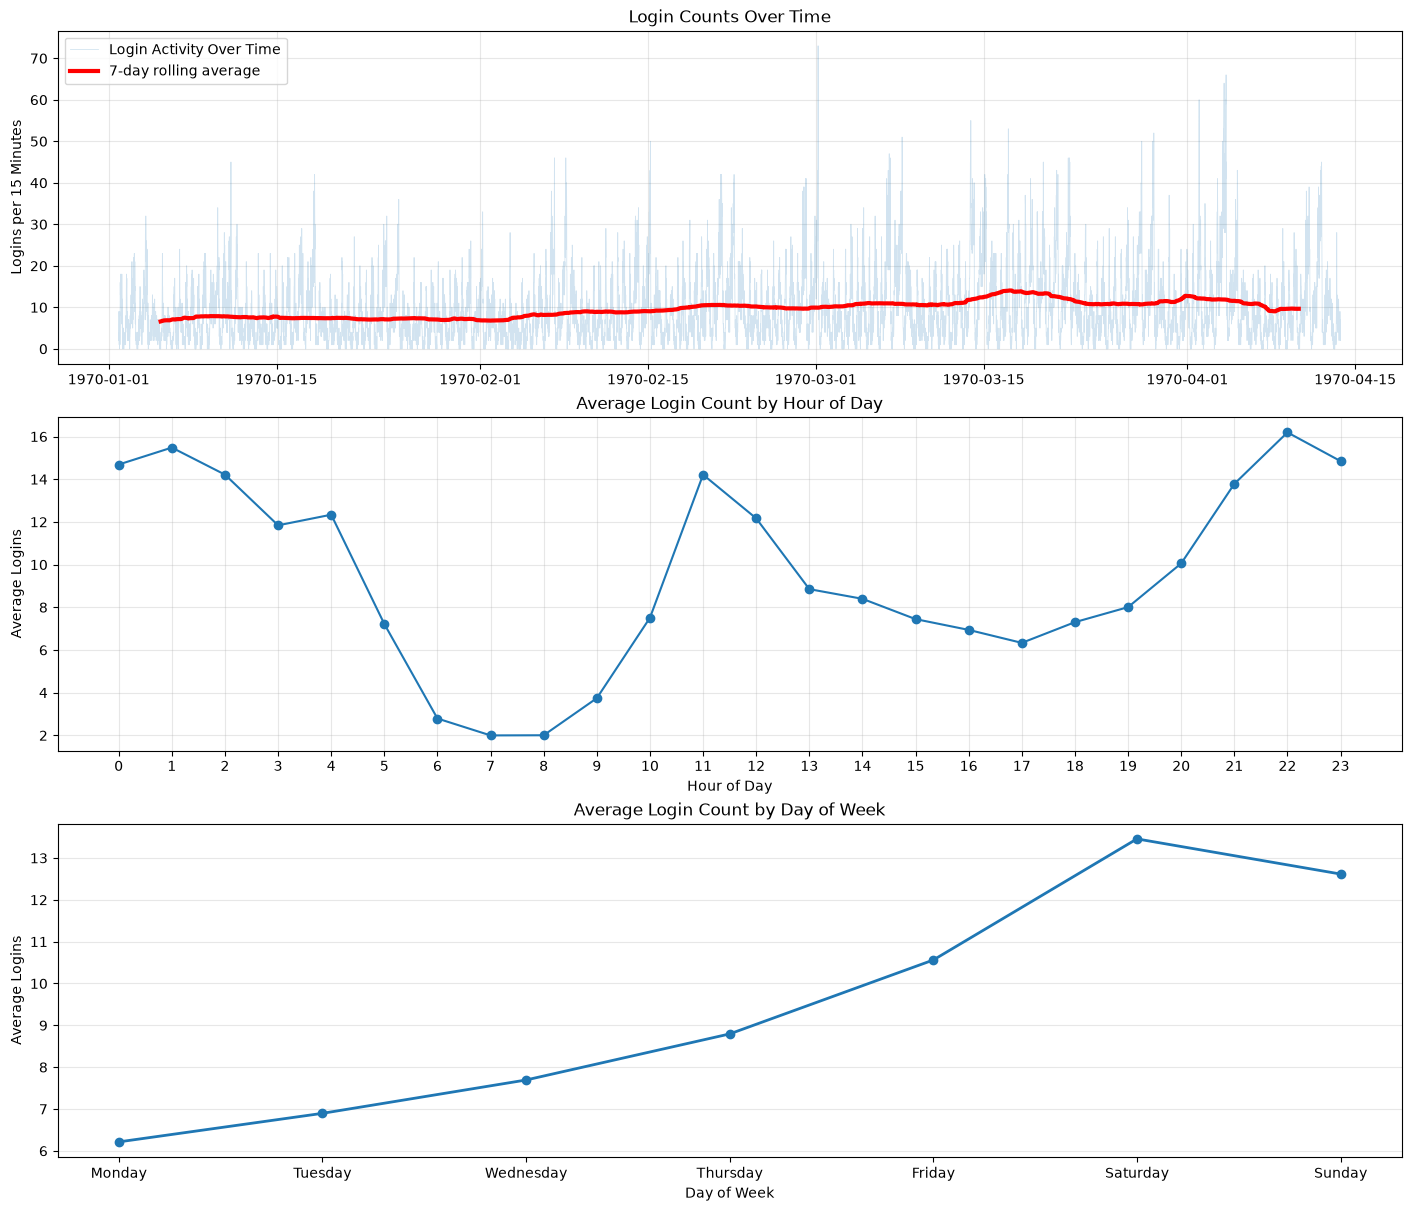

In [9]:
import matplotlib.pyplot as plt

# ---------------------------------------
# Create summary datasets
# ---------------------------------------

# Average login count by hour of day
hourly_avg = (
    login_counts
    .groupby(login_counts.index.hour)["login_count"]
    .mean()
)

# Average login count by day of week
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_avg = (
    login_counts
    .groupby(login_counts.index.day_name())["login_count"]
    .mean()
    .reindex(day_order)
)

daily_avg = (
    login_counts["login_count"]
    .resample("D")
    .mean()
)

rolling_avg = (
    login_counts["login_count"]
    .rolling(window=96*7, center=True)
    .mean()
)

# ---------------------------------------
# Create stacked figure
# ---------------------------------------

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 12),
    constrained_layout=True
)

# ---------------------------------------
# Overall Time Series
# ---------------------------------------

# Raw 15-minute counts
axes[0].plot(
    login_counts.index,
    login_counts["login_count"],
    alpha=0.2,
    linewidth=0.6,
    label="Login Activity Over Time",
)

## Daily average
#axes[0].plot(
#    daily_avg.index,
#    daily_avg.values,
#    color="orange",
#    linewidth=2.5,
#    label="Daily average"
#)

# Rolling average
axes[0].plot(
    rolling_avg.index,
    rolling_avg.values,
    color="red",
    linewidth=3,
    label="7-day rolling average"
)

axes[0].set_title("Login Counts Over Time")
axes[0].set_ylabel("Logins per 15 Minutes")
axes[0].grid(alpha=0.3)
axes[0].legend()

# ---------------------------------------
# Average by Hour
# ---------------------------------------

axes[1].plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o"
)

axes[1].set_title("Average Login Count by Hour of Day")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Logins")
axes[1].set_xticks(range(24))
axes[1].grid(alpha=0.3)

# ---------------------------------------
# Average by Day of Week
# ---------------------------------------

#axes[2].bar(
#    weekday_avg.index,
#    weekday_avg.values
#)
axes[2].plot(
    weekday_avg.index,
    weekday_avg.values,
    marker="o",
    linewidth=2
)

axes[2].set_title("Average Login Count by Day of Week")
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Average Logins")
axes[2].grid(axis="y", alpha=0.3)

plt.show()

### Time Series Summary

The login data exhibit clear temporal patterns over the study period. Individual 15-minute intervals show substantial short-term variability, with frequent spikes in login activity throughout the dataset. A 7-day rolling average reveals a gradual increase in overall login activity from early January through mid-March, followed by a modest decline toward the end of the observation period.

The aggregated views highlight strong cyclical behavior. Average login activity follows a distinct daily pattern, with the lowest demand occurring during the early morning hours (approximately 6:00–8:00 a.m.), a secondary peak around late morning, and the highest demand during the late evening (approximately 10:00 p.m.). Weekly patterns are also evident, with average login activity increasing steadily throughout the work week, peaking on Saturday, and remaining elevated on Sunday.

These findings indicate that user demand is driven primarily by predictable daily and weekly usage cycles rather than random variation alone.

In [10]:
# Average login count by day of week and hour of day
heatmap_data = (
    login_counts
    .assign(
        Day=login_counts.index.day_name(),
        Hour=login_counts.index.hour
    )
    .groupby(["Day", "Hour"])["login_count"]
    .mean()
    .unstack()
    .reindex(day_order)
)

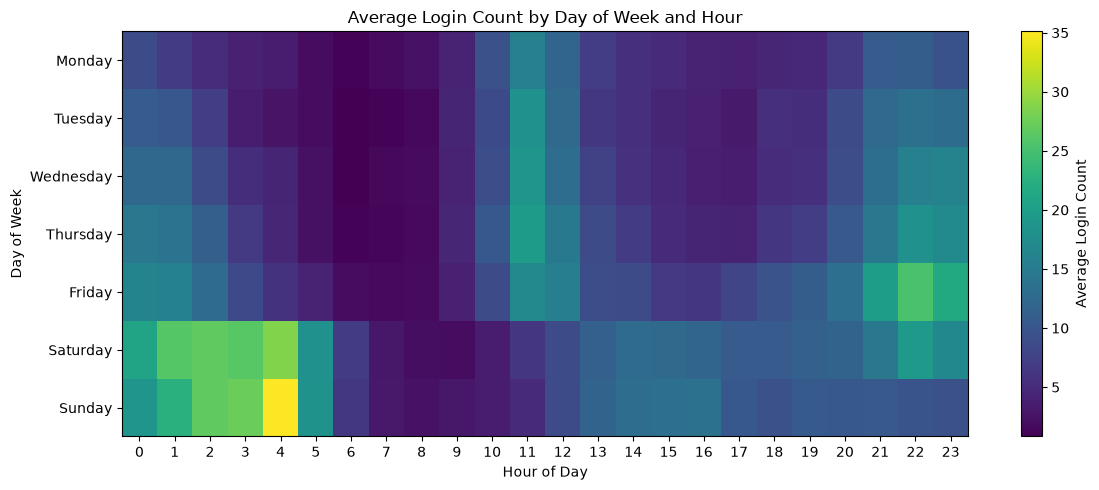

In [11]:
plt.figure(figsize=(12, 5))

plt.imshow(
    heatmap_data,
    aspect="auto",
   # cmap="YlOrRd",
    cmap="viridis",
    origin="upper"
)

plt.colorbar(label="Average Login Count")

plt.xticks(range(24), range(24))
plt.yticks(range(7), day_order)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Average Login Count by Day of Week and Hour")

plt.tight_layout()
plt.show()

### Day-of-Week and Hour-of-Day Patterns

The heatmap combines the daily and weekly demand cycles into a single visualization, revealing several patterns that were less apparent in the individual summary plots.

Weekday login activity follows a relatively consistent schedule, with a pronounced late-morning peak around 11:00 a.m. and lower activity during the early morning hours. Friday begins to transition toward weekend behavior, with elevated login activity during the late evening.

Weekend usage differs substantially from weekdays. Saturday and Sunday experience their highest login activity between approximately midnight and 5:00 a.m., indicating that users remain active much later into the night. In contrast, the weekday late-morning peak is less pronounced on weekends, and activity remains relatively elevated throughout the afternoon.

Overall, the heatmap demonstrates that login demand is strongly influenced by both the day of the week and the time of day, suggesting predictable behavioral patterns rather than random fluctuations.

# Part 2: Experiment and Metrics Design

## Objective

Ultimate is considering reimbursing toll costs for driver partners traveling between Gotham and Metropolis. The goal of the experiment is to determine whether eliminating the toll barrier encourages drivers to operate in both cities, thereby improving service availability during periods of complementary demand.

### 1. Key Measure of Success

The primary measure of success should be the percentage of active drivers completing at least one trip in both cities during the observation period.

This metric directly measures the desired behavioral change. The objective of the proposed policy is not simply to increase the number of trips or total revenue, but rather to encourage drivers to operate across both cities instead of remaining exclusive to one market.

While additional metrics such as total trips, rider wait times, and driver earnings are valuable secondary outcomes, the percentage of cross-city drivers provides the clearest indicator of whether the toll reimbursement successfully changes driver behavior.

### 2a. Experimental Design

A randomized controlled experiment should be conducted.

#### Hypotheses

- **Null hypothesis (H₀):** Reimbursing bridge tolls does not change the proportion of drivers serving both cities.
- **Alternative hypothesis (H₁):** Reimbursing bridge tolls increases the proportion of drivers serving both cities.

Eligible drivers would be randomly assigned to one of two groups:

- **Treatment group:** Drivers receive full reimbursement for all bridge tolls during the study period.
- **Control group:** Drivers continue operating under the existing toll policy.

Random assignment minimizes selection bias and increases confidence that any observed differences between the groups are attributable to the toll reimbursement rather than other factors.

The experiment should run for several weeks to capture weekday and weekend driving patterns while minimizing the influence of short-term fluctuations such as holidays or unusual weather.

### 2b. Statistical Analysis

At the conclusion of the experiment, the primary outcome—the proportion of drivers operating in both cities—would be compared between the treatment and control groups.

A two-proportion z-test (or equivalently, a chi-square test of independence) would be appropriate for determining whether the observed difference is statistically significant.

Additional analyses could compare:

- Average number of cross-city trips per driver
- Driver earnings
- Rider wait times
- Trip completion rates

Continuous outcomes such as earnings or wait times could be analyzed using two-sample t-tests or nonparametric alternatives if distributional assumptions are not satisfied.

Statistical significance would be evaluated using a significance level of α = 0.05, accompanied by confidence intervals to estimate the magnitude of the observed effect. Both statistical significance and practical significance should be considered when interpreting the results.

### 2c. Interpretation and Recommendations

If the treatment group demonstrates a statistically significant increase in the proportion of drivers serving both cities without negatively affecting driver earnings or operational efficiency, Ultimate should consider implementing the toll reimbursement program more broadly.

However, statistical significance alone should not determine the final decision. Management should also evaluate the practical impact of the policy, including:

- Increased rider availability during peak demand
- Reduced passenger wait times
- Changes in driver utilization
- Cost of toll reimbursements relative to increased revenue

Several caveats should also be considered. The experiment should be conducted over a sufficiently long period to account for normal weekly demand cycles. Seasonal effects, special events, and driver adaptation over time may influence the results. In addition, drivers who know they are participating in an experiment may temporarily alter their behavior (the Hawthorne effect), so longer-term monitoring following implementation would be advisable.

Potential confounding factors such as holidays, severe weather, major public events, or changes in rider demand should also be considered when interpreting the results, as these external influences could affect driver behavior independently of the toll reimbursement program.

# Part 3: Predictive Modeling

## Objective

The objective of this analysis is to identify the factors associated with rider retention and develop a predictive model capable of predicting whether a user will remain active six months after account creation. According to the challenge instructions, a rider is considered **retained** if they completed at least one trip during the 30 days preceding the data extraction date. :contentReference[oaicite:0]{index=0}

The analysis will focus on:

- Cleaning and preparing the rider dataset.
- Defining the rider retention outcome.
- Exploring relationships between user characteristics and retention.
- Developing and evaluating predictive machine learning models.
- Identifying the most important predictors of rider retention.
- Providing business recommendations to improve long-term customer retention.

In [12]:
# Define the path to the data
data_path = Path("ultimate_data_challenge.json")

# Confirm the file exists
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path.resolve()}")

# Load the JSON file
with open(data_path, "r") as file:
    rider_data = json.load(file)

# Inspect the structure
print(f"Object type: {type(rider_data)}")
print(f"Number of records: {len(rider_data):,}")
print("\nFirst record:")
print(rider_data[0])

Object type: <class 'list'>
Number of records: 50,000

First record:
{'city': "King's Landing", 'trips_in_first_30_days': 4, 'signup_date': '2014-01-25', 'avg_rating_of_driver': 4.7, 'avg_surge': 1.1, 'last_trip_date': '2014-06-17', 'phone': 'iPhone', 'surge_pct': 15.4, 'ultimate_black_user': True, 'weekday_pct': 46.2, 'avg_dist': 3.67, 'avg_rating_by_driver': 5.0}


In [13]:
# Convert to a DataFrame
df = pd.DataFrame(rider_data)

display(df.head())

print("\nDataset Shape:", df.shape)

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9



Dataset Shape: (50000, 12)


In [14]:
# DataFrame information
df.info()

print("\nMissing Values")
display(df.isna().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics")
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  str    
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  str    
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  str    
 6   phone                   49604 non-null  str    
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), str(4)
memory usage: 6.0 MB

Missing Values


city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64


Duplicate Rows: 8

Summary Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,50000,3,Winterfell,23336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trips_in_first_30_days,50000.0,NaN,NaN,NaN,2.2782,3.792684,0.0,0.0,1.0,3.0,125.0
signup_date,50000,31,2014-01-18,2948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_rating_of_driver,41878.0,NaN,NaN,NaN,4.601559,0.617338,1.0,4.3,4.9,5.0,5.0
avg_surge,50000.0,NaN,NaN,NaN,1.074764,0.222336,1.0,1.0,1.0,1.05,8.0
last_trip_date,50000,182,2014-06-29,2036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phone,49604,2,iPhone,34582,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surge_pct,50000.0,NaN,NaN,NaN,8.849536,19.958811,0.0,0.0,0.0,8.6,100.0
ultimate_black_user,50000,2,False,31146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekday_pct,50000.0,NaN,NaN,NaN,60.926084,37.081503,0.0,33.3,66.7,100.0,100.0


### Initial Data Inspection

The dataset contains **50,000 rider records** and **12 variables** describing account information, early trip behavior, rider and driver ratings, surge usage, and trip timing.

Most variables are complete, but three columns contain missing values:

- `avg_rating_of_driver`: 8,122 missing values
- `phone`: 396 missing values
- `avg_rating_by_driver`: 201 missing values

The largest amount of missingness occurs in `avg_rating_of_driver`, which may indicate that some users did not rate their drivers or had insufficient trip history to produce an average rating. The missing values in `phone` and `avg_rating_by_driver` are much less common.

The dataset also contains **8 duplicate rows**, which should be investigated and likely removed before modeling.

Several numeric variables appear right-skewed or contain unusually large values. For example, `trips_in_first_30_days` has a maximum of 125 despite a median of 1, and `avg_dist` reaches 160.96 miles despite a median of 3.88 miles. These values are not necessarily errors, but they should be examined during exploratory analysis.

The date variables are currently stored as strings and will need to be converted to datetime format before defining the retention outcome.

In [15]:
# Create a working copy
riders = df.copy()

# Convert date columns to datetime
riders["signup_date"] = pd.to_datetime(
    riders["signup_date"],
    errors="coerce"
)

riders["last_trip_date"] = pd.to_datetime(
    riders["last_trip_date"],
    errors="coerce"
)

# Remove exact duplicate rows
riders = riders.drop_duplicates().reset_index(drop=True)

# Verify the results
print(f"Rows after removing duplicates: {len(riders):,}")
print("\nInvalid dates:")
print(riders[["signup_date", "last_trip_date"]].isna().sum())

riders.info()

Rows after removing duplicates: 49,992

Invalid dates:
signup_date       0
last_trip_date    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 49992 entries, 0 to 49991
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    49992 non-null  str           
 1   trips_in_first_30_days  49992 non-null  int64         
 2   signup_date             49992 non-null  datetime64[us]
 3   avg_rating_of_driver    41873 non-null  float64       
 4   avg_surge               49992 non-null  float64       
 5   last_trip_date          49992 non-null  datetime64[us]
 6   phone                   49596 non-null  str           
 7   surge_pct               49992 non-null  float64       
 8   ultimate_black_user     49992 non-null  bool          
 9   weekday_pct             49992 non-null  float64       
 10  avg_dist                49992 non-null  float64       
 11  avg_ratin

## Define Rider Retention

The challenge defines a retained rider as one who completed at least one trip during the 30 days preceding the data extraction date. Because the latest recorded trip occurred on June 30, 2014, this date is used as the reference point for defining retention.

A binary target variable (`retained`) is created, where:

- **1** = User completed a trip on or after June 1, 2014.
- **0** = User did not complete a trip during the preceding 30 days.

In [16]:
# Determine the observation date
observation_date = riders["last_trip_date"].max()

print("Observation Date:", observation_date.date())

Observation Date: 2014-07-01


In [17]:
# Users active within the previous 30 days are considered retained
retention_cutoff = observation_date - pd.Timedelta(days=30)

riders["retained"] = (
    riders["last_trip_date"] >= retention_cutoff
).astype(int)

#riders["retained"].value_counts()

In [18]:
retention_summary = (
    riders["retained"]
    .value_counts()
    .rename(index={0: "Not Retained", 1: "Retained"})
    .to_frame("Count")
)

retention_summary["Percent"] = (
    retention_summary["Count"] / len(riders) * 100
).round(1)

display(retention_summary)

,Count,Percent
retained,,
Not Retained,31188,62.4
Retained,18804,37.6


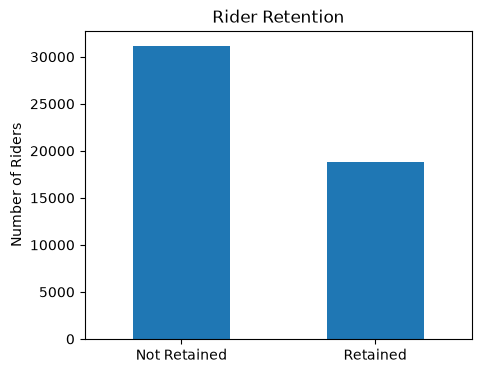

In [19]:

retention_summary["Count"].plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Rider Retention")
plt.ylabel("Number of Riders")
plt.xlabel("")
plt.xticks(rotation=0)

plt.show()

### Rider Retention

Using the challenge definition of retention, a rider is considered retained if they completed at least one trip during the 30 days preceding the observation date (June 30, 2014).

After removing duplicate records, **18,804 of 49,992 riders (37.6%)** met the retention criterion, while **31,188 riders (62.4%)** were not retained. This indicates that approximately two-thirds of riders were inactive during the month preceding data collection.

The moderate class imbalance is unlikely to pose significant challenges for predictive modeling, although evaluation metrics beyond overall accuracy (such as precision, recall, F1-score, and ROC AUC) should be considered when assessing model performance.

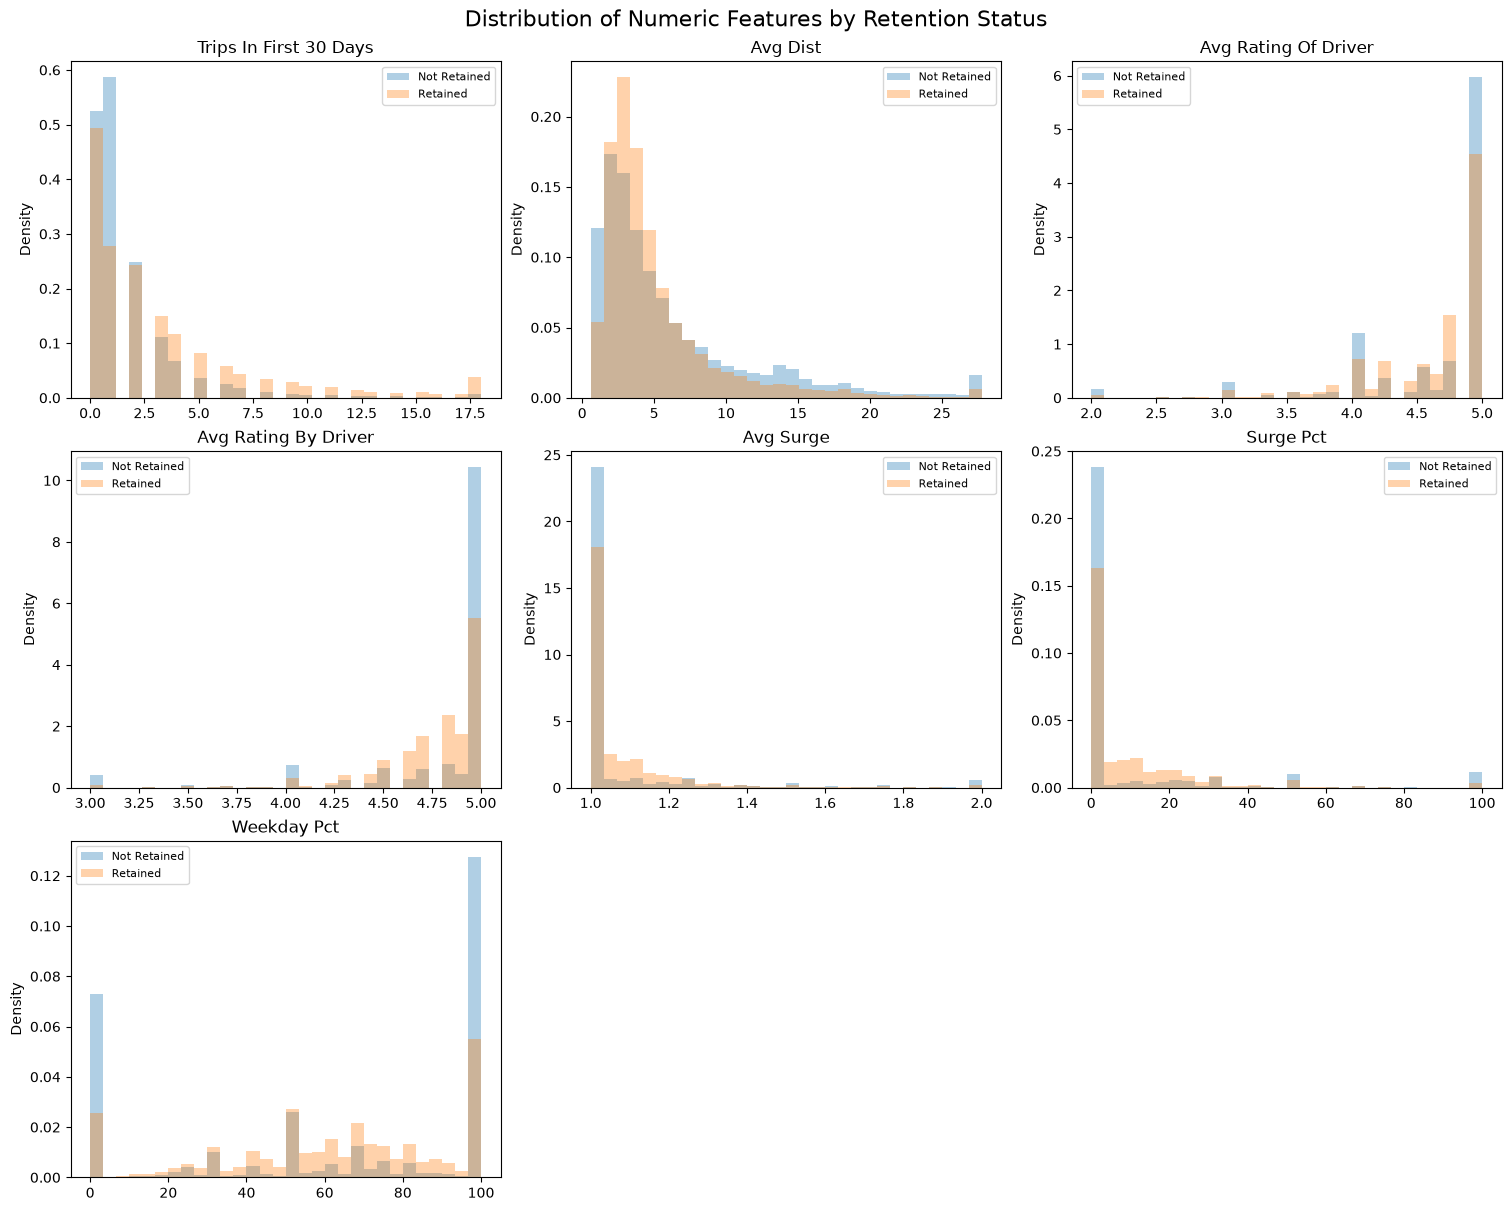

In [20]:

# Create a copy for visualization only
plot_data = riders.copy()

# Numeric variables to visualize
numeric_features = [
    "trips_in_first_30_days",
    "avg_dist",
    "avg_rating_of_driver",
    "avg_rating_by_driver",
    "avg_surge",
    "surge_pct",
    "weekday_pct"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()

# Clip values at the 1st and 99th percentiles for plotting
for i, feature in enumerate(numeric_features):
    lower = plot_data[feature].quantile(0.01)
    upper = plot_data[feature].quantile(0.99)
    plot_data[feature] = plot_data[feature].clip(lower=lower, upper=upper)

    bins = np.linspace(
        plot_data[feature].min(),
        plot_data[feature].max(),
        31
    )
    
    # Not retained
    plot_data.loc[riders["retained"] == 0, feature].plot(
        kind="hist",
        bins=bins,
        density=True,
        alpha=0.35,
        ax=axes[i],
        label="Not Retained"
    )

    # Retained
    plot_data.loc[riders["retained"] == 1, feature].plot(
        kind="hist",
        bins=bins,
        density=True,
        alpha=0.35,
        ax=axes[i],
        label="Retained"
    )

    axes[i].set_title(feature.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

# Remove unused axes
for ax in axes[len(numeric_features):]:
    fig.delaxes(ax)

plt.suptitle("Distribution of Numeric Features by Retention Status", fontsize=16)

plt.show()

### Numeric Feature Comparison

The distributions of several numeric variables differ noticeably between retained and non-retained riders.

The strongest separation is observed for **trips in the first 30 days**, where retained riders generally completed substantially more trips shortly after joining the platform. This suggests that early engagement is strongly associated with long-term retention.

Retained riders also exhibit higher values for **surge percentage**, indicating they are more willing to travel during periods of increased demand. Smaller differences are observed for **average trip distance**, **average rating by driver**, and **average rating of driver**, while **average surge multiplier** and **weekday trip percentage** show considerable overlap between the two groups.

Overall, the distributions suggest that early usage patterns are likely to be more predictive of rider retention than rider ratings or typical travel behavior.

In [21]:
# Calculate retention rates for categorical variables
city_retention = (
    riders.groupby("city")["retained"]
    .mean()
    .sort_values(ascending=False)
)

phone_retention = (
    riders.groupby("phone")["retained"]
    .mean()
    .sort_values(ascending=False)
)

black_retention = (
    riders.groupby("ultimate_black_user")["retained"]
    .mean()
)

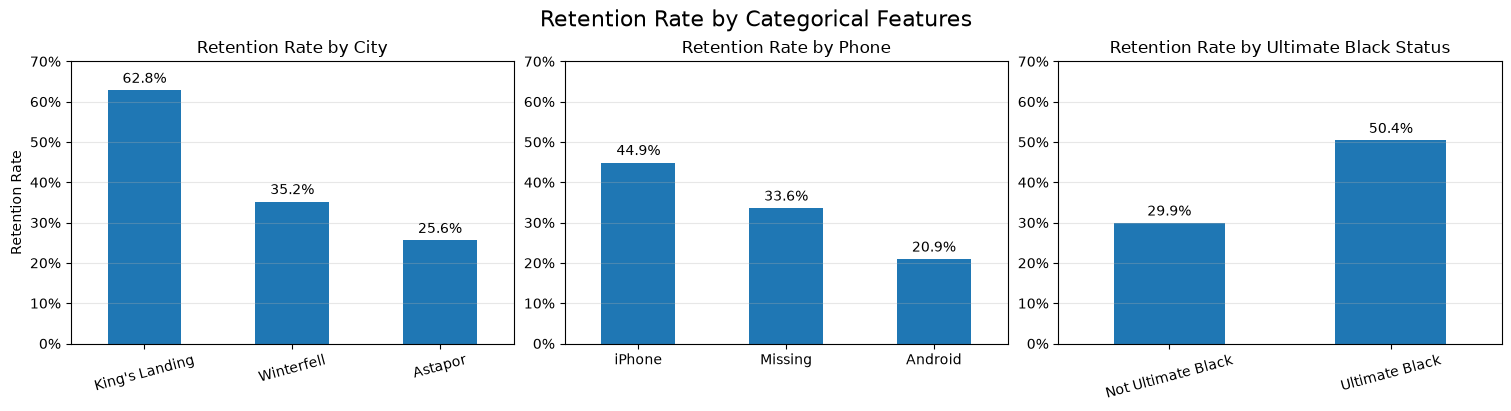

In [22]:

# Calculate retention rates for each categorical feature
city_retention = (
    riders.groupby("city")["retained"]
    .mean()
    .sort_values(ascending=False)
)

phone_retention = (
    riders.groupby("phone", dropna=False)["retained"]
    .mean()
    .sort_values(ascending=False)
)

black_retention = (
    riders.groupby("ultimate_black_user")["retained"]
    .mean()
    .rename(index={
        False: "Not Ultimate Black",
        True: "Ultimate Black"
    })
)

# Replace the missing phone label for plotting
phone_retention.index = phone_retention.index.fillna("Missing")

# Create the figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    constrained_layout=True
)

# Retention by city
city_retention.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Retention Rate by City")
axes[0].set_xlabel("")
axes[0].set_ylabel("Retention Rate")
axes[0].tick_params(axis="x", rotation=15)

# Retention by phone
phone_retention.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Retention Rate by Phone")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=0)

# Retention by Ultimate Black usage
black_retention.plot(
    kind="bar",
    ax=axes[2]
)

axes[2].set_title("Retention Rate by Ultimate Black Status")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=15)

# Format all y-axes as percentages and use the same scale
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_ylim(0, 0.7)
    ax.grid(axis="y", alpha=0.3)

    # Add percentage labels above the bars
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{value:.1%}" for value in container.datavalues],
            padding=3
        )

fig.suptitle(
    "Retention Rate by Categorical Features",
    fontsize=16
)

plt.show()

### Categorical Feature Comparison

Several categorical variables exhibit substantial differences in rider retention.

Retention rates vary considerably by **city**, ranging from **25.6%** in Astapor to **62.8%** in King's Landing, suggesting that geographic location is strongly associated with long-term rider activity.

Phone type also appears to be an important factor. Riders using **iPhones** have the highest retention rate (**44.9%**), compared with **20.9%** for Android users. Records with missing phone information fall between these two groups, indicating that missingness may itself contain useful predictive information.

The strongest relationship is observed for **Ultimate Black membership**. Riders enrolled in Ultimate Black are retained at a rate of **50.4%**, compared with **29.9%** for non-members, suggesting that subscription status is a strong indicator of long-term engagement.

Overall, these results indicate that city, phone type, and Ultimate Black membership are likely to be important predictors of rider retention.

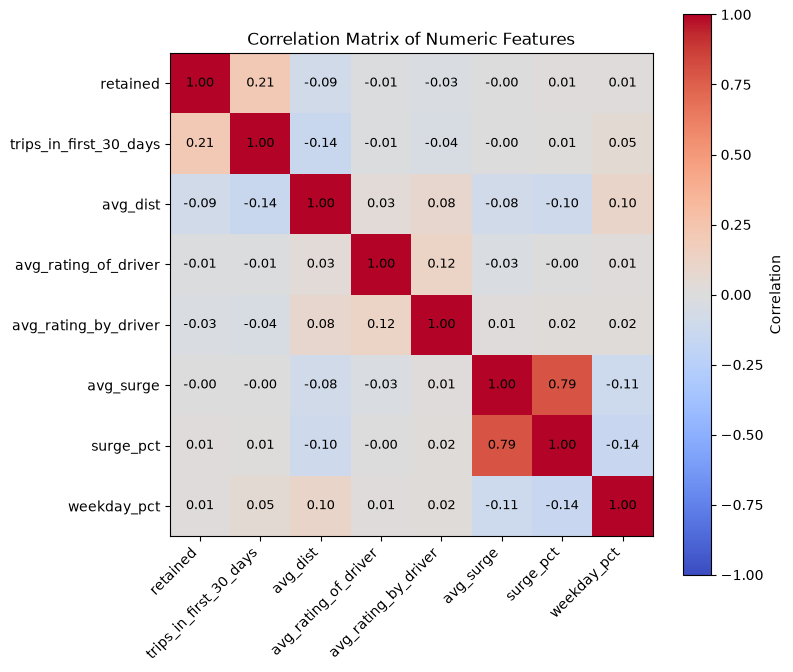

In [23]:


# Select numeric features plus the target
corr_features = [
    "retained",
    "trips_in_first_30_days",
    "avg_dist",
    "avg_rating_of_driver",
    "avg_rating_by_driver",
    "avg_surge",
    "surge_pct",
    "weekday_pct"
]

# Compute the correlation matrix
corr = riders[corr_features].corr()

# Plot
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Tick labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Add correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Correlation")

plt.title("Correlation Matrix of Numeric Features")

plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation matrix indicates that most numeric variables have relatively weak linear relationships with rider retention. Among the features examined, **trips in the first 30 days** exhibits the strongest positive correlation with retention (r = 0.21), suggesting that riders who are more active shortly after joining the platform are more likely to remain active over the long term.

Most other variables show only weak individual correlations with retention, indicating that rider retention is likely influenced by a combination of factors rather than any single numeric feature.

The strongest relationship among the predictor variables is between **average surge multiplier** and **surge percentage** (r = 0.79), suggesting substantial overlap in the information captured by these two variables. While this level of correlation may introduce multicollinearity in linear models, it is generally less problematic for tree-based machine learning algorithms.

## Feature Engineering and Data Preparation

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from IPython.display import Image, display, HTML


In [25]:
# Create modeling DataFrame
model_data = riders.copy()

# Median imputation for numeric variables
model_data["avg_rating_of_driver"] = (
    model_data["avg_rating_of_driver"]
    .fillna(model_data["avg_rating_of_driver"].median())
)

model_data["avg_rating_by_driver"] = (
    model_data["avg_rating_by_driver"]
    .fillna(model_data["avg_rating_by_driver"].median())
)

# Treat missing phone values as their own category
model_data["phone"] = model_data["phone"].fillna("Missing")

# Verify
print(model_data.isna().sum())

city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
last_trip_date            0
phone                     0
surge_pct                 0
ultimate_black_user       0
weekday_pct               0
avg_dist                  0
avg_rating_by_driver      0
retained                  0
dtype: int64


In [26]:
# Convert Boolean to integer
model_data["ultimate_black_user"] = (
    model_data["ultimate_black_user"]
    .astype(int)
)

# One-hot encode categorical variables
model_data = pd.get_dummies(
    model_data,
    columns=["city", "phone"],
    drop_first=True,
    dtype=int
)

In [27]:
# Remove date columns from the model data
model_data = model_data.drop(
    columns=[
        "signup_date",
        "last_trip_date"
    ]
)

In [28]:
# Create X and y
X = model_data.drop(columns="retained")
y = model_data["retained"]

print(X.shape)
print(y.shape)

(49992, 12)
(49992,)


In [29]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(39993, 12)
(9999, 12)


In [30]:


# Columns to scale
numeric_columns = [
    "trips_in_first_30_days",
    "avg_rating_of_driver",
    "avg_surge",
    "surge_pct",
    "weekday_pct",
    "avg_dist",
    "avg_rating_by_driver"
]

# Copy data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale numeric variables
scaler = StandardScaler()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

### Fit and evaluate a Logistic regression model

In [31]:

# Train the model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [32]:
# Predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [33]:
print("Logistic Regression Performance")
print("-" * 35)

print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_log):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_log):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_log):.3f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance
-----------------------------------
Accuracy : 0.719
Precision: 0.675
Recall   : 0.490
F1 Score : 0.568
ROC AUC  : 0.759

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.86      0.79      6238
           1       0.67      0.49      0.57      3761

    accuracy                           0.72      9999
   macro avg       0.71      0.67      0.68      9999
weighted avg       0.71      0.72      0.71      9999



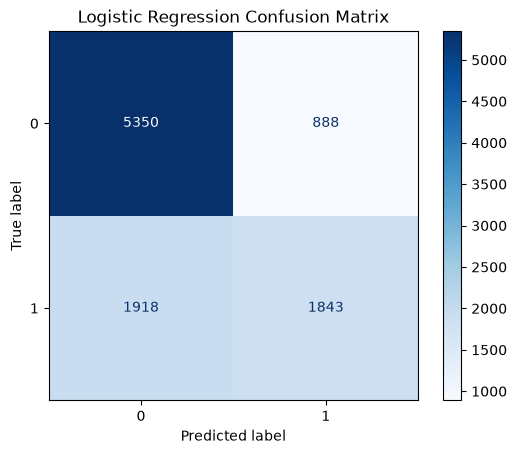

In [34]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [35]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC AUC"
])

results.loc[len(results)] = [
    "Logistic Regression",
    accuracy_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_log),
    roc_auc_score(y_test, y_prob_log)
]

In [36]:
# Extract model coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
})

# Calculate absolute magnitude for sorting
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

#display(coef_df)

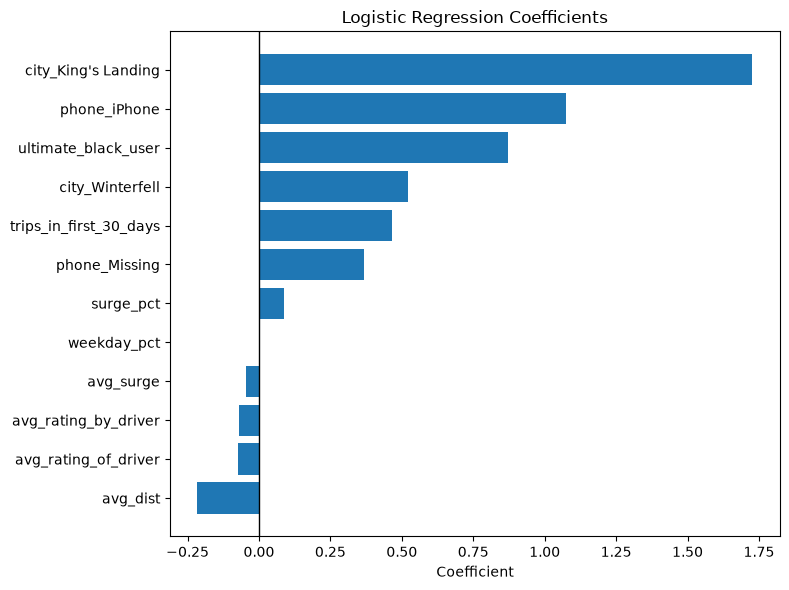

In [37]:
# Five largest positive and five largest negative coefficients
coef_plot = pd.concat([
    coef_df.nsmallest(6, "Coefficient"),
    coef_df.nlargest(6, "Coefficient")
])

coef_plot = coef_plot.sort_values("Coefficient")

plt.figure(figsize=(8, 6))

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"]
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Logistic Regression Coefficients")
#plt.title("Most Influential Logistic Regression Coefficients")
plt.xlabel("Coefficient")

plt.tight_layout()

fig_log = plt.gcf()
ax_log = plt.gca()

# Display the titled version in the notebook
display(fig_log)

# Remove the title only from the saved image
ax_log.set_title("")
fig_log.savefig(
    "logistic_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

# Prevent Jupyter from displaying the figure again
plt.close(fig_log)

Positive coefficients indicate features associated with increased odds of rider retention, while negative coefficients indicate features associated with decreased odds of retention. Because the model contains both standardized continuous variables and binary indicator variables, coefficient magnitudes should not be interpreted as a direct ranking of feature importance.

### Random Forest Model

In [38]:


# Train the model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [39]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Random Forest Performance")
print("-" * 35)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf):.3f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
-----------------------------------
Accuracy : 0.755
Precision: 0.676
Recall   : 0.671
F1 Score : 0.673
ROC AUC  : 0.824

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      6238
           1       0.68      0.67      0.67      3761

    accuracy                           0.76      9999
   macro avg       0.74      0.74      0.74      9999
weighted avg       0.75      0.76      0.76      9999



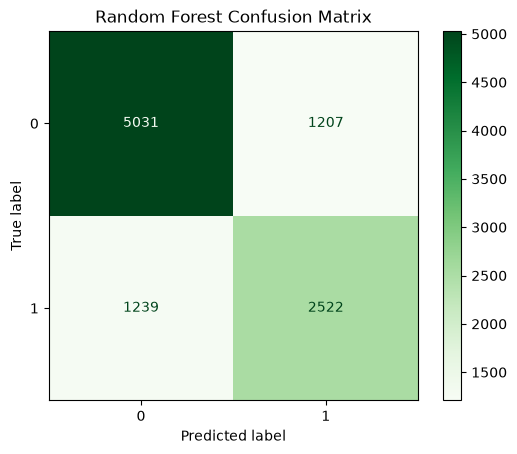

In [41]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [42]:
results.loc[len(results)] = [
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf)
]

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.719,0.675,0.490,0.568,0.759
1,Random Forest,0.755,0.676,0.671,0.673,0.824


In [43]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance.head(15))

,Feature,Importance
6,avg_dist,0.300555
5,weekday_pct,0.129325
7,avg_rating_by_driver,0.117276
0,trips_in_first_30_days,0.080365
3,surge_pct,0.080092
1,avg_rating_of_driver,0.078847
2,avg_surge,0.068497
8,city_King's Landing,0.062632
11,phone_iPhone,0.034074
4,ultimate_black_user,0.031037


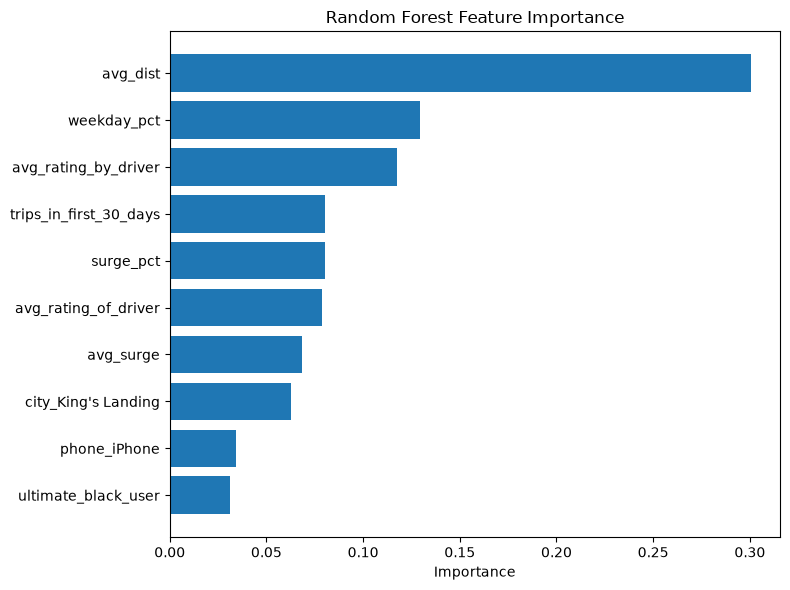

In [44]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()

fig_rf = plt.gcf()
ax_rf = plt.gca()

# Display the titled version in the notebook
display(fig_rf)

# Remove the title only from the saved image
ax_rf.set_title("")
fig_rf.savefig(
    "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

# Prevent Jupyter from displaying the figure again
plt.close(fig_rf)



The Random Forest feature importance identifies the variables that contributed most to the model's predictions. Continuous variables, particularly average trip distance, weekday trip percentage, rider ratings, and trips completed during the first 30 days, were among the strongest predictors of retention.

Unlike Logistic Regression coefficients, Random Forest feature importance measures the contribution of each feature to predictive performance rather than the direction of its relationship with the outcome. Furthermore, impurity-based feature importance tends to favor continuous variables with many possible split points. Consequently, these importance values should be interpreted as relative predictive contributions rather than causal effects.

### Model Comparison

Both Logistic Regression and Random Forest produced reasonable predictive performance; however, the Random Forest classifier consistently outperformed Logistic Regression across nearly every evaluation metric.

While overall accuracy improved modestly (75.5% versus 71.9%), the largest gains were observed in recall and F1-score. Random Forest correctly identified a substantially larger proportion of retained riders while maintaining nearly identical precision. The model also achieved a higher ROC AUC (0.824 versus 0.759), indicating superior discrimination between retained and non-retained users across a range of classification thresholds.

Because Random Forest demonstrated better overall predictive performance and is capable of modeling nonlinear relationships and feature interactions, it was selected as the final model for interpreting the factors associated with rider retention.

In [45]:

HTML("""
<table>
<tr>
<td align="center">
<b>Logistic Regression Coefficients</b><br>
<img src="logistic_coefficients.png" width="450">
</td>
<td align="center">
<b>Random Forest Feature Importance</b><br>
<img src="rf_feature_importance.png" width="450">
</td>
</tr>
</table>
""")

Logistic Regression Coefficients,Random Forest Feature Importance


### ROC Curve

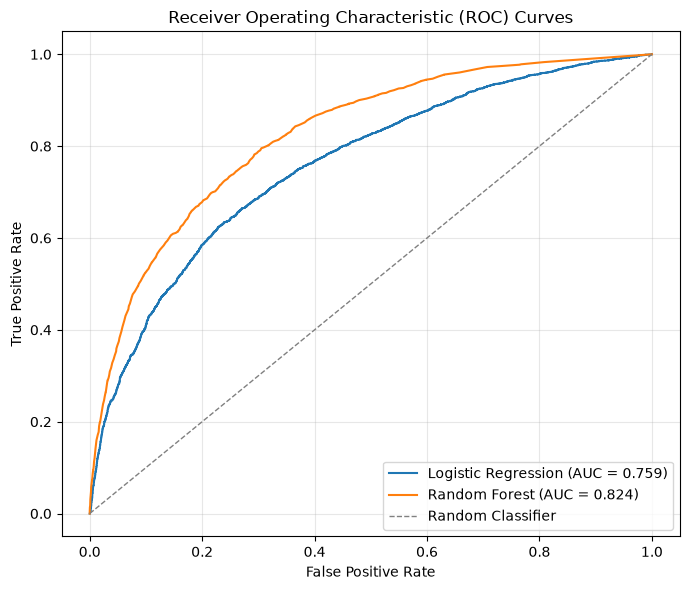

In [46]:

# Calculate ROC points
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC values
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot both curves on one graph
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# No-skill reference line
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Random Classifier"
)

plt.title("Receiver Operating Characteristic (ROC) Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curves provide a threshold-independent comparison of the two classification models. The Random Forest model consistently outperformed Logistic Regression across nearly the entire range of false positive rates, indicating superior discrimination between retained and non-retained riders.

The Random Forest achieved an ROC AUC of **0.824**, compared with **0.759** for Logistic Regression, confirming the results observed in the performance metrics. Because it provides better overall classification performance while capturing nonlinear relationships and feature interactions, the Random Forest model was selected as the final predictive model.

## Business Recommendations

Based on the exploratory analysis and predictive modeling, the following recommendations could help improve rider retention:

1. **Encourage early rider engagement.**
   - Trips completed during the first 30 days were among the strongest predictors of long-term retention. Offering onboarding incentives, promotional ride credits, or personalized reminders during a rider's first month may encourage continued platform usage.

2. **Develop targeted retention strategies for infrequent and long-distance riders.**
   - Riders with longer average trip distances were less likely to be retained, and average trip distance was the most influential predictor in the Random Forest model. Further investigation into this user segment may identify opportunities to improve their experience through pricing, promotions, or service availability.

3. **Expand successful premium service offerings.**
   - Ultimate Black membership was positively associated with rider retention in the Logistic Regression model. Understanding what aspects of the premium experience encourage continued engagement may help Ultimate strengthen customer loyalty across a broader user base.

4. **Tailor retention initiatives by market.**
   - Retention rates varied substantially across cities, suggesting that rider behavior differs by market. City-specific marketing campaigns and retention strategies may be more effective than a single nationwide approach.

5. **Use the Random Forest model to prioritize retention efforts.**
   - The Random Forest model achieved the best overall predictive performance (ROC AUC = 0.824) and could be used to identify riders at higher risk of churn. Targeted retention campaigns focused on these riders may improve marketing efficiency while reducing customer attrition.

## Limitations

This analysis has several limitations that should be considered when interpreting the results:

1. **Retention Definition**
   - Rider retention was defined as having at least one trip within the 30 days preceding the end of the observation period. While reasonable for this analysis, other definitions of retention or churn may produce different results.

2. **Observational Data**
   - The dataset is observational and captures associations rather than causal relationships. Features identified as important predictors of retention should not be interpreted as direct causes of rider retention.

3. **Feature Availability**
   - The analysis was limited to the variables provided in the dataset. Other factors that may influence rider retention, such as pricing, promotions, weather, customer service interactions, and competitor activity, were not available.

4. **Model Interpretation**
   - Logistic Regression coefficients indicate the direction of association between predictors and retention, while Random Forest feature importance reflects predictive contribution rather than causal influence. These measures should be interpreted accordingly.

5. **Generalizability**
   - The models were developed using historical data from a specific time period. Rider behavior and business conditions may change over time, requiring periodic model retraining and validation to maintain predictive performance.

## Conclusion

The objective of this analysis was to identify the factors associated with rider retention and develop a predictive model capable of distinguishing retained from non-retained riders. Exploratory data analysis revealed meaningful differences between retained and non-retained riders across several behavioral and demographic characteristics, particularly early rider activity, trip distance, city, and Ultimate Black membership.

Two classification models were evaluated. While Logistic Regression provided an interpretable baseline and identified the direction of relationships between individual predictors and rider retention, the Random Forest classifier consistently achieved superior predictive performance. The Random Forest model improved accuracy, recall, F1-score, and ROC AUC, achieving an ROC AUC of **0.824** compared with **0.759** for Logistic Regression. These results demonstrate that nonlinear relationships and feature interactions play an important role in predicting rider retention.

Feature importance analysis identified **average trip distance**, **weekday usage patterns**, **driver ratings**, and **trips completed during the first 30 days** as the strongest predictors of rider retention. Together with the exploratory analysis, these findings suggest that encouraging early rider engagement, developing targeted retention strategies for specific rider segments, and tailoring retention efforts by market could improve long-term customer retention.

Overall, the Random Forest model provides a strong foundation for identifying riders at risk of churn and supporting data-driven customer retention strategies. Future work could incorporate additional behavioral and operational variables, evaluate alternative machine learning algorithms, and periodically retrain the model as rider behavior evolves over time.